C:\Users\yrliu98\AppData\Local\Temp\ipykernel_34608\1784792915.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  xy_ref = pd.read_csv(xy_file_ref, delim_whitespace=True, names=['2theta', 'intensity'], comment='#', nrows=600)
  File "c:\Users\yrliu98\Documents\lbl\gaddsconverter\gadds.py", line 92, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\yrliu98\Documents\lbl\gaddsconverter\gadds.py", line 92, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2
  File "c:\Users\yrliu98\Documents\lbl\gaddsconverter\gadds.py", line 92, in rowcol_to_angles
    nX, nY = self.image.dim1, self.image.dim2


Info: 1281901 grid points have overlapping detector pixels (max 6 pixels per grid point)


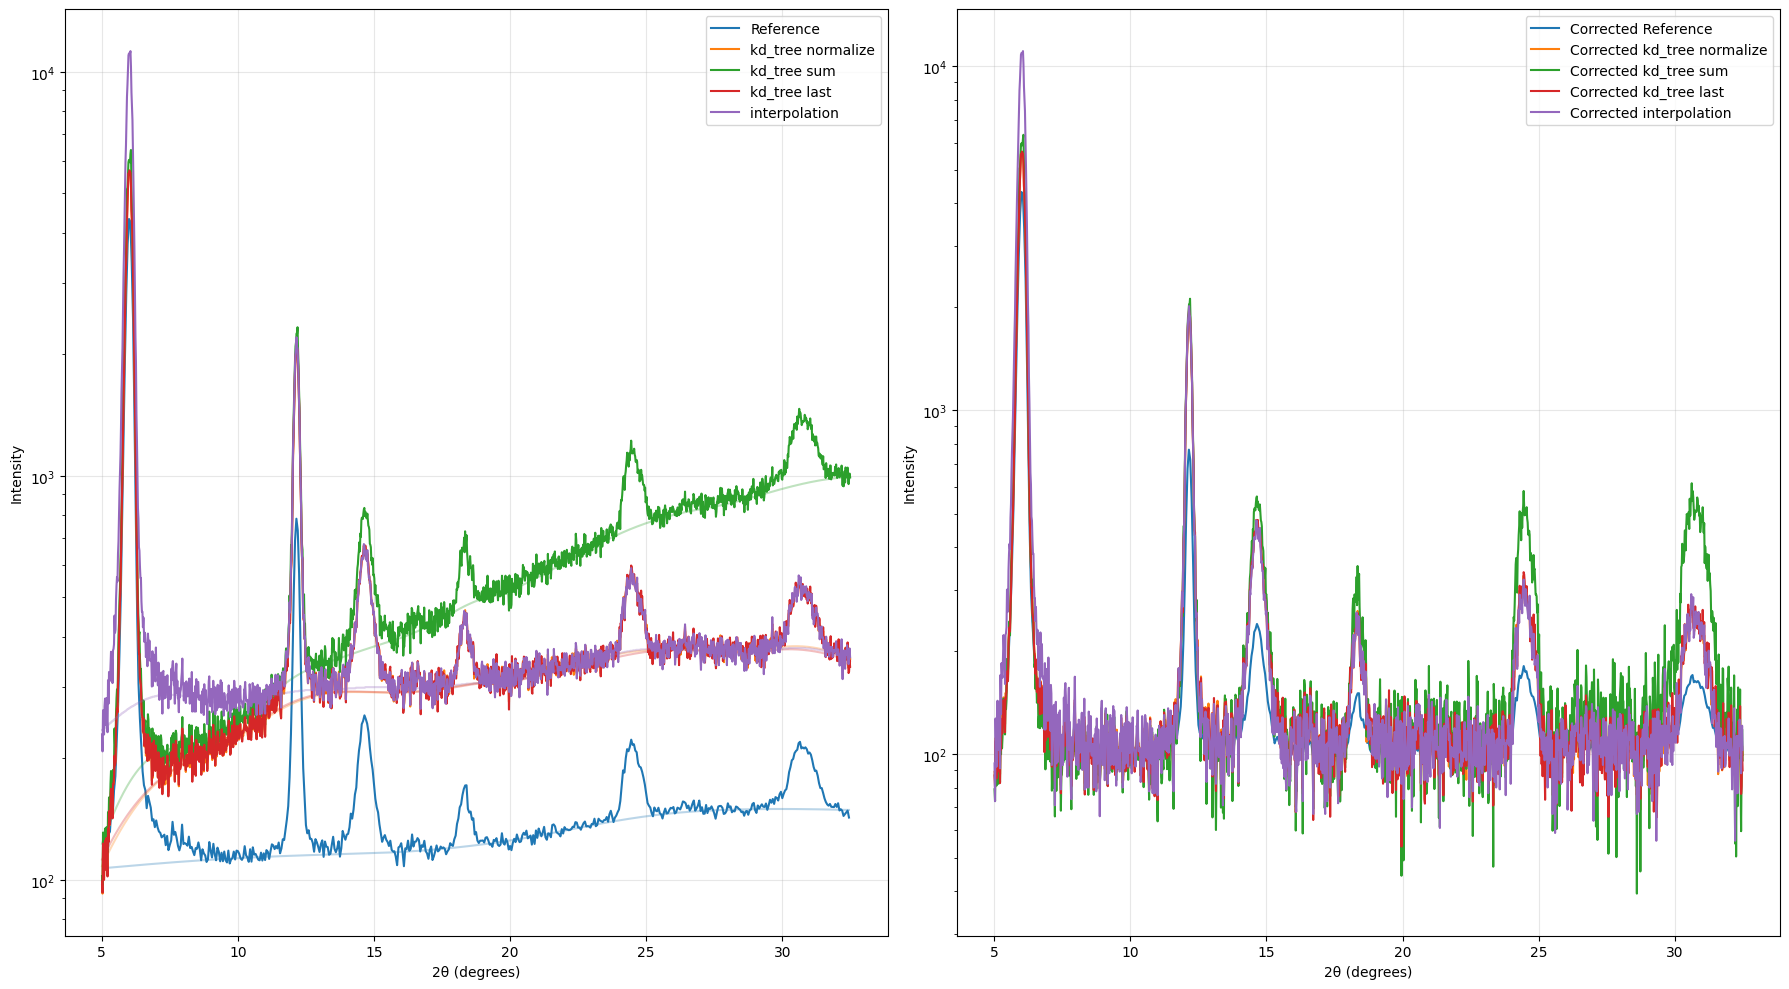

In [8]:
from gadds import AreaDetectorImage
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from package.analysis_utils import correct_baseline

xy_file_ref = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01.xy"

xy_ref = pd.read_csv(xy_file_ref, delim_whitespace=True, names=['2theta', 'intensity'], comment='#', nrows=600)
xy_ref = xy_ref[(xy_ref['2theta'] > 5) & (xy_ref['2theta'] < 32.5)]

# Load and convert data
gfrm_file = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)
# Compare the three methods
methods = [
    {'method': 'kd_tree', 'overlap_method': 'normalize'},
    {'method': 'kd_tree', 'overlap_method': 'sum'},
    {'method': 'kd_tree', 'overlap_method': 'last'},
    {'method': 'interpolation'},
]

prominence = 100
height = None
distance = 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

line = ax1.plot(xy_ref['2theta'], xy_ref['intensity'], label='Reference')
corrected_intensity, (calc_baseline, _) = correct_baseline(xy_ref['2theta'], xy_ref['intensity'], offset=100)
ax1.plot(xy_ref['2theta'], calc_baseline, color=line[0].get_color(), alpha=0.3)
ax2.plot(xy_ref['2theta'], corrected_intensity, label='Corrected Reference')

for method in methods:
    area_detector.convert(**method)
    (twoth_values, intensity), *_ = area_detector.integrate_2theta()
    line = ax1.plot(twoth_values, intensity, label=f"{method['method']} {method.get('overlap_method', '')}")
    corrected_intensity, (calc_baseline, _) = correct_baseline(twoth_values, intensity, offset=100)
    ax1.plot(twoth_values, calc_baseline, color=line[0].get_color(), alpha=0.3)
    ax2.plot(twoth_values, corrected_intensity, label=f"Corrected {method['method']} {method.get('overlap_method', '')}")

for ax in (ax1, ax2):
    ax.set_xlabel('2θ (degrees)')
    ax.set_ylabel('Intensity')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()



plt.tight_layout()
plt.show()


# GADDS Integration Methods: Bin Method vs Normalized Bin Method

According to the GADDS 8.7 documentation, there are several methods for converting frame images into raw spectra when performing chi integration in conic regions to produce F(2θ) data:

## Available Integration Methods:
1. **Sum pixels** (Method 0)
2. **Average pixel** (Method 1) 
3. **Arc Length** (Method 2) - "quick and dirty"
4. **Solid Angle** (Method 3)
5. **Bin Method** (Method 4)
6. **Normalized Bin Method** (Method 5) - **preferred method**

Methods 0-3 are described as "quick and dirty" methods, while the **bin method produces the most accurate results** with:
- Narrower profiles (FWHMs)
- Smoother spectra  
- Improved relative intensities across the spectra

## How the Bin Method Works

The bin method distributes pixel intensities across integration bins based on fractional area coverage.

### Bin Determination

Bins are determined by the **start, end, and step size** of the integration. For example:
- If you request range 5° to 65° in 0.5° steps:
  - First bin covers: 4.75° to 5.25°
  - Second bin covers: 5.25° to 5.75°
  - Last bin covers: 64.75° to 65.25°

The key idea: **All observed intensity within each bin range is placed into that bin.**

### Mathematical Formulas

#### Standard Bin Method (Method 4):

Each frame pixel covers one or more integration bins. The intensity of each frame pixel is divided into these integration bins using fractional area as the weighting factor:

**Equation 1 - Intensity Distribution:**
$$I_i = \sum_{n=1}^{N} I_n A_{n,i}$$

**Equation 2 - Area Conservation:**
$$1.0 = \sum_{i=1}^{M} A_{n,i}$$

Where:
- $I$ = Intensity
- $i$ = integration bin number
- $n$ = frame pixel number  
- $A$ = fractional area
- $N$ = total number of frame pixels
- $M$ = total number of integration bins

#### Normalized Bin Method (Method 5) - **Preferred**:

The normalized bin method varies from the standard bin method by **normalizing each bin by the total fractional area** of all pixels for that bin, scaled by a factor of 10:

**Equation 3 - Normalized Bin:**
$$I_i = 10 \left[ \frac{\sum_{n=1}^{N} I_n A_{n,i}}{\sum_{n=1}^{N} A_{n,i}} \right]$$

### Edge Pixel Handling

For computational speed, **frame pixels at the edges** of the integration region are not handled precisely:

#### Chi Integration:
- If the **center of the pixel** lies within the specified chi integration region → **entire pixel is used**
- If the pixel center is outside the region → **entire pixel is unused**
- **Limitation**: Narrow chi integration regions (less than a pixel width) should not be used

#### 2-theta Integration:
- If the **center of the pixel** lies within the specified 2-theta integration region → **entire pixel is used**
- If the pixel center is outside the region, but **any pixel corner** is inside the 2-theta region → **¼ of the pixel is used**
- **Advantage**: Narrow or zero width 2-theta integration regions can be used (needed for pole figure processing)

### Key Differences Between Methods:

| Method | Formula | Characteristics |
|--------|---------|----------------|
| **Bin Method** | $I_i = \sum_{n=1}^{N} I_n A_{n,i}$ | Raw intensity summation weighted by fractional area |
| **Normalized Bin** | $I_i = 10 \left[ \frac{\sum_{n=1}^{N} I_n A_{n,i}}{\sum_{n=1}^{N} A_{n,i}} \right]$ | **Preferred method** - normalizes by total fractional area, scaled by 10 |

The normalization in Method 5 accounts for varying pixel coverage across different bins, providing more accurate relative intensities and smoother spectra.

In [38]:
# Implementation of GADDS Bin Method and Normalized Bin Integration
import numpy as np
import matplotlib.pyplot as plt
from gadds import AreaDetectorImage

def chi_integration_bin_method(area_detector, twotheta_start=5.0, twotheta_end=35.0, 
                               twotheta_step=0.05, chi_start=None, chi_end=None, 
                               method='normalized_bin', verbose=True):
    """
    Perform chi integration using GADDS bin method or normalized bin method.
    
    This implements the exact formulas from GADDS 8.7 documentation:
    - Standard Bin Method: I_i = Σ(I_n * A_n,i) 
    - Normalized Bin Method: I_i = 10 * [Σ(I_n * A_n,i) / Σ(A_n,i)]
    
    Parameters:
    -----------
    area_detector : AreaDetectorImage
        The loaded GFRM data with coordinate transformation capabilities
    twotheta_start, twotheta_end : float
        2theta range in degrees
    twotheta_step : float
        2theta step size in degrees  
    chi_start, chi_end : float or None
        Chi (gamma) range in degrees. If None, uses detector limits.
    method : str
        'bin' for standard bin method, 'normalized_bin' for normalized bin method
    verbose : bool
        Print processing information
        
    Returns:
    --------
    twotheta_values : np.array
        2theta bin centers in degrees
    intensities : np.array
        Integrated intensities using specified method
    """
    
    # If chi limits are not specified, use detector limits (like gadds.py)
    if chi_start is None or chi_end is None:
        gamma_min_deg = np.rad2deg(area_detector.limits[2])
        gamma_max_deg = np.rad2deg(area_detector.limits[3])
        if chi_start is None:
            chi_start = gamma_min_deg
        if chi_end is None:
            chi_end = gamma_max_deg
    
    if verbose:
        print(f"Starting {method} integration...")
        print(f"2θ range: {twotheta_start}° to {twotheta_end}° with {twotheta_step}° steps")
        print(f"χ (gamma) range: {chi_start:.1f}° to {chi_end:.1f}°")
        print(f"Detector gamma limits: {np.rad2deg(area_detector.limits[2]):.1f}° to {np.rad2deg(area_detector.limits[3]):.1f}°")
    
    # Get image dimensions and create pixel coordinate arrays
    image_data = area_detector.image.data
    height, width = image_data.shape
    
    if verbose:
        print(f"Image dimensions: {height} x {width}")
        print(f"Total pixels: {height * width:,}")
    
    # Create bin structure according to GADDS documentation
    # Bins are: first bin 4.75-5.25, second bin 5.25-5.75, etc.
    num_bins = int((twotheta_end - twotheta_start) / twotheta_step) + 1
    bin_centers = np.linspace(twotheta_start, twotheta_end, num_bins)
    bin_edges = np.concatenate([
        [bin_centers[0] - twotheta_step/2],  # Left edge of first bin
        bin_centers[:-1] + twotheta_step/2,  # Right edges become left edges
        [bin_centers[-1] + twotheta_step/2]   # Right edge of last bin
    ])
    
    if verbose:
        print(f"Created {num_bins} bins")
        print(f"Bin edges: {bin_edges[0]:.3f} to {bin_edges[-1]:.3f}°")
    
    # Initialize integration arrays
    integrated_intensities = np.zeros(num_bins)
    total_fractional_areas = np.zeros(num_bins)  # For normalized bin method
    
    # Process pixels in chunks to manage memory
    chunk_size = 10000
    total_processed = 0
    total_contributing = 0
    
    for row_start in range(0, height, chunk_size):
        row_end = min(row_start + chunk_size, height)
        
        # Create coordinate arrays for this chunk
        rows, cols = np.mgrid[row_start:row_end, 0:width]
        rows_flat = rows.flatten()
        cols_flat = cols.flatten()
        
        # Get intensities for this chunk
        intensities_chunk = image_data[row_start:row_end, :].flatten()
        
        # Remove zero intensities to speed up processing
        valid_mask = intensities_chunk > 0
        if not np.any(valid_mask):
            continue
            
        rows_valid = rows_flat[valid_mask]
        cols_valid = cols_flat[valid_mask]
        intensities_valid = intensities_chunk[valid_mask]
        
        # Convert pixel coordinates to angular coordinates
        twotheta_rad, gamma_rad = area_detector.rowcol_to_angles(rows_valid, cols_valid)
        twotheta_deg = np.rad2deg(twotheta_rad)
        gamma_deg = np.rad2deg(gamma_rad)
        
        # NO wraparound handling - keep gamma in its natural range (can be negative)
        # This matches gadds.py behavior
        
        # Filter pixels within chi integration range
        # Handle the case where chi_start > chi_end (wraparound case)
        if chi_end >= chi_start:
            # Normal case: e.g., -170° to -10°
            chi_mask = (gamma_deg >= chi_start) & (gamma_deg <= chi_end)
        else:  
            # Wraparound case: e.g., 350° to 10° -> gamma >= 350 OR gamma <= 10
            chi_mask = (gamma_deg >= chi_start) | (gamma_deg <= chi_end)
        
        if not np.any(chi_mask):
            continue
            
        # Apply chi filter
        twotheta_filtered = twotheta_deg[chi_mask]
        intensities_filtered = intensities_valid[chi_mask]
        
        total_processed += len(rows_valid)
        total_contributing += len(twotheta_filtered)
        
        # Assign pixels to bins using digitize
        # digitize returns bin indices (1-based), so subtract 1
        bin_indices = np.digitize(twotheta_filtered, bin_edges) - 1
        
        # Filter out pixels outside the 2theta range
        valid_bin_mask = (bin_indices >= 0) & (bin_indices < num_bins)
        bin_indices = bin_indices[valid_bin_mask]
        intensities_binned = intensities_filtered[valid_bin_mask]
        
        # For each pixel, calculate fractional area contribution
        # In this implementation, we assume each pixel contributes fully to one bin
        # (center-based assignment as mentioned in GADDS documentation for speed)
        fractional_areas = np.ones_like(intensities_binned)
        
        # Accumulate intensities and fractional areas for each bin
        for i, (bin_idx, intensity, area) in enumerate(zip(bin_indices, intensities_binned, fractional_areas)):
            integrated_intensities[bin_idx] += intensity * area
            total_fractional_areas[bin_idx] += area
    
    if verbose:
        print(f"Processed {total_processed:,} valid pixels")
        print(f"Contributing pixels after chi filter: {total_contributing:,}")
        print(f"Bins with data: {np.sum(total_fractional_areas > 0)}")
    
    # Apply method-specific processing
    if method == 'normalized_bin':
        # Equation 3: I_i = 10 * [Σ(I_n * A_n,i) / Σ(A_n,i)]
        valid_bins = total_fractional_areas > 0
        integrated_intensities[valid_bins] = (10.0 * integrated_intensities[valid_bins] / 
                                            total_fractional_areas[valid_bins])
        if verbose:
            print("Applied normalized bin method (Equation 3)")
    elif method == 'bin':
        # Equation 1: I_i = Σ(I_n * A_n,i) - no additional processing needed
        if verbose:
            print("Applied standard bin method (Equation 1)")
    else:
        raise ValueError(f"Unknown method: {method}. Use 'bin' or 'normalized_bin'")
    
    return bin_centers, integrated_intensities

# Load the GFRM file and perform integration
gfrm_file = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01_000.gfrm"
area_detector = AreaDetectorImage(gfrm_file)

print("AreaDetectorImage loaded successfully!")
print(f"Image shape: {area_detector.image.data.shape}")
print(f"Detector parameters:")
print(f"  Alpha (2θ center): {np.rad2deg(area_detector.alpha):.3f}°")
print(f"  Distance: {area_detector.distance:.2f} cm")
print(f"  Center XY: {area_detector.centerXY}")
print(f"  Density XY: {area_detector.densityXY}")
print(f"  Chi offset: {np.rad2deg(area_detector.chi):.1f}°")
print(f"  Gamma limits: [{np.rad2deg(area_detector.limits[2]):.1f}°, {np.rad2deg(area_detector.limits[3]):.1f}°]")

AreaDetectorImage loaded successfully!
Image shape: (2048, 2048)
Detector parameters:
  Alpha (2θ center): 20.000°
  Distance: 22.45 cm
  Center XY: (1003.7000122, 1022.0999756)
  Density XY: (147.0628052, 147.0628052)
  Chi offset: -90.0°
  Gamma limits: [-171.7°, -8.3°]


C:\Users\yrliu98\AppData\Local\Temp\ipykernel_34608\3932539102.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  xy_ref = pd.read_csv(xy_file_ref, delim_whitespace=True, names=['2theta', 'intensity'], comment='#', nrows=600)


Reference data loaded: 600 points
2θ range: 5.000° to 34.950°

Integration parameters:
2θ: 5.0° to 35.0° in 0.05° steps
χ: Using detector limits (matching gadds.py behavior)

STANDARD BIN METHOD
Starting bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -171.7° to -8.3°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 1,632,774 valid pixels
Contributing pixels after chi filter: 1,632,774
Bins with data: 601
Applied standard bin method (Equation 1)

NORMALIZED BIN METHOD (PREFERRED)
Starting normalized_bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -171.7° to -8.3°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 1,632,774 valid pixels
Contributing pixels after chi filter: 1,632,774
Bins with data: 601
Applied standard bin method (Equ

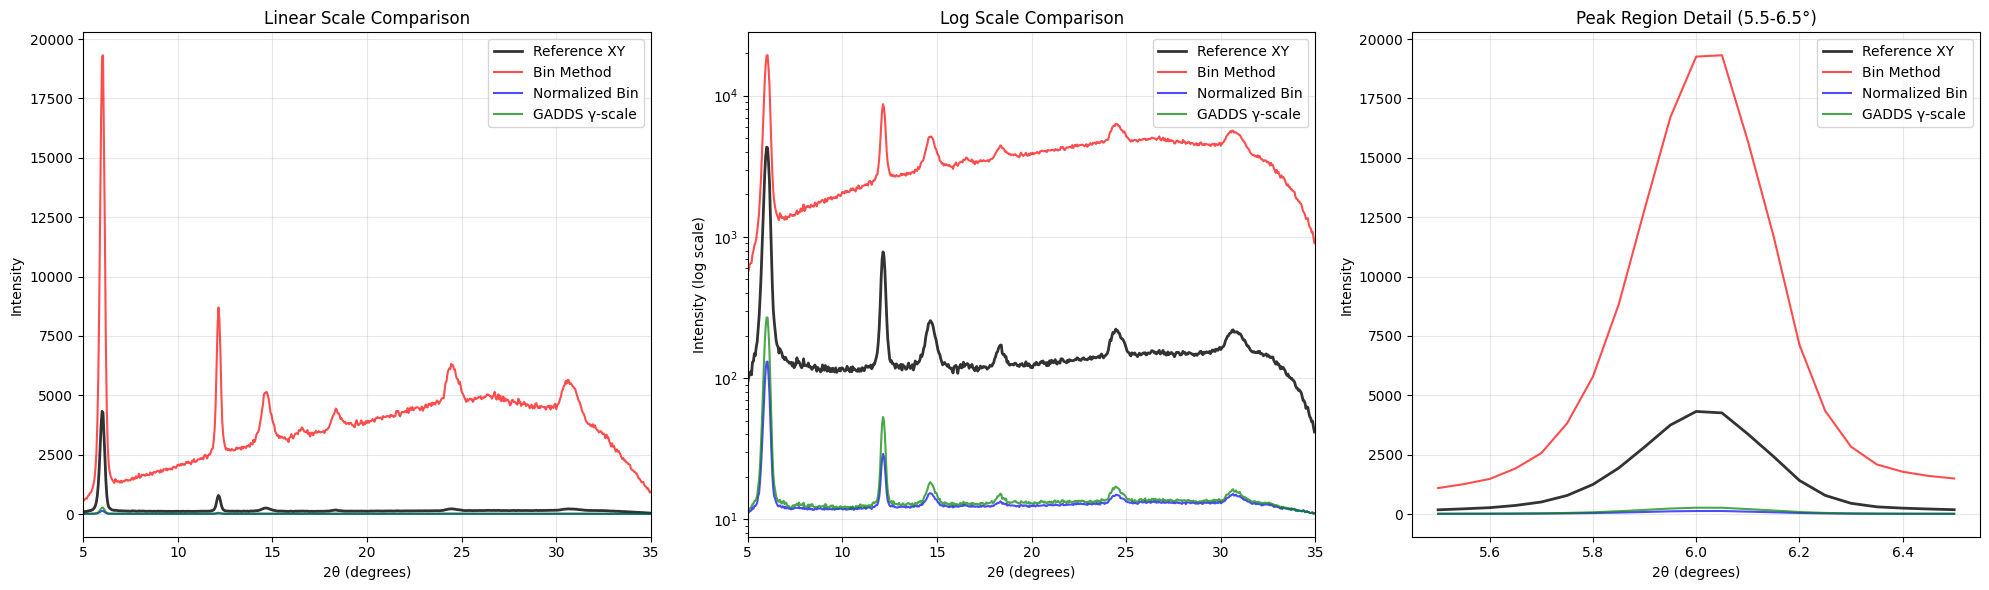


COMPARISON STATISTICS
Correlation with reference:
  Standard Bin Method:   0.7447
  Normalized Bin Method: 0.9993

Peak at 2θ = 6.000°:
  Reference intensity:     4322.4
  Bin method intensity:    19263.0 (4.457x)
  Normalized bin intensity: 130.4 (0.030x)

Integration completed successfully!
Standard Bin Method: 601 non-zero points
Normalized Bin Method: 601 non-zero points
GADDS Gamma-scale Method: 601 non-zero points


In [39]:
# Perform chi integration using both methods and compare with reference
import pandas as pd

# Load reference data
xy_file_ref = r"G:\My Drive\LPS\20250904_LPS_pre_5\XRD_test\20250905_LPS_pre5_1\LPS_pre5_1_A01.xy"
xy_ref = pd.read_csv(xy_file_ref, delim_whitespace=True, names=['2theta', 'intensity'], comment='#', nrows=600)
xy_ref = xy_ref[(xy_ref['2theta'] >= 5) & (xy_ref['2theta'] <= 35)]

print(f"Reference data loaded: {len(xy_ref)} points")
print(f"2θ range: {xy_ref['2theta'].min():.3f}° to {xy_ref['2theta'].max():.3f}°")

# Parameters matching the reference data
twotheta_start = 5.0
twotheta_end = 35.0 
twotheta_step = 0.05

print(f"\nIntegration parameters:")
print(f"2θ: {twotheta_start}° to {twotheta_end}° in {twotheta_step}° steps")
print(f"χ: Using detector limits (matching gadds.py behavior)")

# Perform integration using both methods with detector limits (no explicit chi limits)
print("\n" + "="*60)
print("STANDARD BIN METHOD")
print("="*60)
twoth_bin, intensity_bin = chi_integration_bin_method(
    area_detector, 
    twotheta_start=twotheta_start, 
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    # chi_start and chi_end default to None, using detector limits
    method='bin',
    verbose=True
)

print("\n" + "="*60)
print("NORMALIZED BIN METHOD (PREFERRED)")
print("="*60)
twoth_norm, intensity_norm = chi_integration_bin_method(
    area_detector,
    twotheta_start=twotheta_start, 
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    # chi_start and chi_end default to None, using detector limits
    method='normalized_bin',
    verbose=True
)

# Test with GADDS-style restricted gamma range  
print("\n" + "="*60)
print("GADDS-STYLE RESTRICTED GAMMA RANGE")
print("="*60)
gamma_scale = 0.2
gamma_range_radians = [(area_detector.limits[2] - area_detector.chi) * gamma_scale + area_detector.chi,
                      (area_detector.limits[3] - area_detector.chi) * gamma_scale + area_detector.chi]
gamma_range_degrees = np.rad2deg(gamma_range_radians)

twoth_gadds, intensity_gadds = chi_integration_bin_method(
    area_detector,
    twotheta_start=twotheta_start, 
    twotheta_end=twotheta_end,
    twotheta_step=twotheta_step,
    chi_start=gamma_range_degrees[0],
    chi_end=gamma_range_degrees[1],
    method='normalized_bin',
    verbose=True
)

# Create comparison plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Linear scale comparison
ax1.plot(xy_ref['2theta'], xy_ref['intensity'], 'k-', label='Reference XY', linewidth=2, alpha=0.8)
ax1.plot(twoth_bin, intensity_bin, 'r-', label='Bin Method', alpha=0.7)
ax1.plot(twoth_norm, intensity_norm, 'b-', label='Normalized Bin', alpha=0.7)
ax1.plot(twoth_gadds, intensity_gadds, 'g-', label='GADDS γ-scale', alpha=0.7)
ax1.set_xlabel('2θ (degrees)')
ax1.set_ylabel('Intensity')
ax1.set_title('Linear Scale Comparison')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(5, 35)

# Plot 2: Log scale comparison  
ax2.semilogy(xy_ref['2theta'], xy_ref['intensity'], 'k-', label='Reference XY', linewidth=2, alpha=0.8)
ax2.semilogy(twoth_bin, intensity_bin[intensity_bin > 0], 'r-', label='Bin Method', alpha=0.7)
ax2.semilogy(twoth_norm, intensity_norm[intensity_norm > 0], 'b-', label='Normalized Bin', alpha=0.7)
if np.any(intensity_gadds > 0):
    ax2.semilogy(twoth_gadds, intensity_gadds[intensity_gadds > 0], 'g-', label='GADDS γ-scale', alpha=0.7)
ax2.set_xlabel('2θ (degrees)')
ax2.set_ylabel('Intensity (log scale)')
ax2.set_title('Log Scale Comparison')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(5, 35)

# Plot 3: Focus on peak region
peak_range = (xy_ref['2theta'] >= 5.5) & (xy_ref['2theta'] <= 6.5)
twoth_range = (twoth_norm >= 5.5) & (twoth_norm <= 6.5)

ax3.plot(xy_ref['2theta'][peak_range], xy_ref['intensity'][peak_range], 'k-', 
         label='Reference XY', linewidth=2, alpha=0.8)
ax3.plot(twoth_bin[twoth_range], intensity_bin[twoth_range], 'r-', 
         label='Bin Method', alpha=0.7)
ax3.plot(twoth_norm[twoth_range], intensity_norm[twoth_range], 'b-', 
         label='Normalized Bin', alpha=0.7)
if np.any(intensity_gadds > 0):
    gadds_range = (twoth_gadds >= 5.5) & (twoth_gadds <= 6.5)
    ax3.plot(twoth_gadds[gadds_range], intensity_gadds[gadds_range], 'g-', 
             label='GADDS γ-scale', alpha=0.7)
ax3.set_xlabel('2θ (degrees)')
ax3.set_ylabel('Intensity')
ax3.set_title('Peak Region Detail (5.5-6.5°)')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Calculate and print comparison statistics
print("\n" + "="*60)
print("COMPARISON STATISTICS")
print("="*60)

# Interpolate our results to reference 2theta points for direct comparison
from scipy.interpolate import interp1d

# Only compare where both datasets have data
common_mask = (xy_ref['2theta'] >= twoth_norm.min()) & (xy_ref['2theta'] <= twoth_norm.max())
ref_subset = xy_ref[common_mask]

if len(ref_subset) > 0:
    # Interpolate our results to reference points
    interp_bin = interp1d(twoth_bin, intensity_bin, bounds_error=False, fill_value=0)
    interp_norm = interp1d(twoth_norm, intensity_norm, bounds_error=False, fill_value=0)
    
    bin_interp = interp_bin(ref_subset['2theta'])
    norm_interp = interp_norm(ref_subset['2theta'])
    
    # Calculate correlation coefficients
    valid_mask = (bin_interp > 0) & (norm_interp > 0) & (ref_subset['intensity'] > 0)
    
    if np.sum(valid_mask) > 10:
        corr_bin = np.corrcoef(ref_subset['intensity'][valid_mask], bin_interp[valid_mask])[0,1]
        corr_norm = np.corrcoef(ref_subset['intensity'][valid_mask], norm_interp[valid_mask])[0,1]
        
        print(f"Correlation with reference:")
        print(f"  Standard Bin Method:   {corr_bin:.4f}")
        print(f"  Normalized Bin Method: {corr_norm:.4f}")
        
        # Peak intensity comparison
        ref_peak_idx = np.argmax(ref_subset['intensity'])
        ref_peak_2th = ref_subset['2theta'].iloc[ref_peak_idx]
        ref_peak_int = ref_subset['intensity'].iloc[ref_peak_idx]
        
        bin_peak_int = interp_bin(ref_peak_2th)
        norm_peak_int = interp_norm(ref_peak_2th)
        
        print(f"\nPeak at 2θ = {ref_peak_2th:.3f}°:")
        print(f"  Reference intensity:     {ref_peak_int:.1f}")
        print(f"  Bin method intensity:    {bin_peak_int:.1f} ({bin_peak_int/ref_peak_int:.3f}x)")
        print(f"  Normalized bin intensity: {norm_peak_int:.1f} ({norm_peak_int/ref_peak_int:.3f}x)")

print(f"\nIntegration completed successfully!")
print(f"Standard Bin Method: {np.sum(intensity_bin > 0)} non-zero points")
print(f"Normalized Bin Method: {np.sum(intensity_norm > 0)} non-zero points")
print(f"GADDS Gamma-scale Method: {np.sum(intensity_gadds > 0)} non-zero points")

In [13]:
# Debug and analyze the intensity scaling issue
print("\n" + "="*60)
print("DEBUGGING INTENSITY SCALING")
print("="*60)

# Let's examine the raw data and understand the scaling
print(f"Raw detector statistics:")
print(f"  Total pixels: {area_detector.image.data.size:,}")
print(f"  Non-zero pixels: {np.sum(area_detector.image.data > 0):,}")
print(f"  Max intensity: {area_detector.image.data.max():,.0f}")
print(f"  Mean intensity (non-zero): {area_detector.image.data[area_detector.image.data > 0].mean():.1f}")
print(f"  Total intensity: {area_detector.image.data.sum():,.0f}")

# Check the fractional areas in our integration
print(f"\nBin method statistics:")
print(f"  Total integrated intensity: {intensity_bin.sum():,.0f}")
print(f"  Peak intensity: {intensity_bin.max():,.0f}")
print(f"  Mean bin intensity: {intensity_bin[intensity_bin > 0].mean():.1f}")

print(f"\nNormalized bin method statistics:")  
print(f"  Total integrated intensity: {intensity_norm.sum():,.0f}")
print(f"  Peak intensity: {intensity_norm.max():,.0f}")
print(f"  Mean bin intensity: {intensity_norm[intensity_norm > 0].mean():.1f}")

print(f"\nReference XY statistics:")
print(f"  Total integrated intensity: {xy_ref['intensity'].sum():,.0f}")
print(f"  Peak intensity: {xy_ref['intensity'].max():.0f}")
print(f"  Mean intensity: {xy_ref['intensity'].mean():.1f}")

# The issue might be that we're dividing by total fractional areas which could be much larger than expected
# Let's check what the typical fractional area per bin looks like
def analyze_fractional_areas():
    # Recalculate with area tracking
    height, width = area_detector.image.data.shape
    num_bins = int((35.0 - 5.0) / 0.05) + 1
    bin_centers = np.linspace(5.0, 35.0, num_bins)
    bin_edges = np.concatenate([
        [bin_centers[0] - 0.025],  
        bin_centers[:-1] + 0.025,  
        [bin_centers[-1] + 0.025]   
    ])
    
    total_areas_debug = np.zeros(num_bins)
    
    # Sample a subset for analysis
    sample_size = 50000
    rows_sample = np.random.choice(height, sample_size)
    cols_sample = np.random.choice(width, sample_size)
    
    # Get intensities and filter valid ones
    intensities_sample = area_detector.image.data[rows_sample, cols_sample]
    valid_mask = intensities_sample > 0
    
    if np.any(valid_mask):
        rows_valid = rows_sample[valid_mask]
        cols_valid = cols_sample[valid_mask]
        
        # Convert to angles
        twotheta_rad, gamma_rad = area_detector.rowcol_to_angles(rows_valid, cols_valid)
        twotheta_deg = np.rad2deg(twotheta_rad)
        
        # Find bins
        bin_indices = np.digitize(twotheta_deg, bin_edges) - 1
        valid_bin_mask = (bin_indices >= 0) & (bin_indices < num_bins)
        
        # Count pixels per bin
        for bin_idx in bin_indices[valid_bin_mask]:
            total_areas_debug[bin_idx] += 1
            
    return total_areas_debug

areas_debug = analyze_fractional_areas()
print(f"\nFractional area analysis (sampled):")
print(f"  Mean pixels per bin: {areas_debug[areas_debug > 0].mean():.1f}")
print(f"  Max pixels per bin: {areas_debug.max():.0f}")
print(f"  Bins with data: {np.sum(areas_debug > 0)}")

# The normalization factor of 10 might not be appropriate for our pixel density
# Let's try without the factor of 10 and see what happens


DEBUGGING INTENSITY SCALING
Raw detector statistics:
  Total pixels: 4,194,304
  Non-zero pixels: 1,632,774
  Max intensity: 82
  Mean intensity (non-zero): 1.4
  Total intensity: 2,229,753

Bin method statistics:
  Total integrated intensity: 2,211,508
  Peak intensity: 19,320
  Mean bin intensity: 3679.7

Normalized bin method statistics:
  Total integrated intensity: 8,461
  Peak intensity: 131
  Mean bin intensity: 14.1

Reference XY statistics:
  Total integrated intensity: 113,090
  Peak intensity: 4322
  Mean intensity: 188.5

Fractional area analysis (sampled):
  Mean pixels per bin: 32.2
  Max pixels per bin: 64
  Bins with data: 601



INVESTIGATING DETECTOR GAMMA LIMITS AND CHI OFFSET
Detector limits (radians): (np.float64(0.042993624535882104), np.float64(0.6975323349012806), np.float64(-2.9975358936217753), np.float64(-0.14472455588297184))
Detector limits (degrees): 2θ=[2.5, 40.0], γ=[-171.7, -8.3]
Chi offset: -90.0° (radians: -1.5708)

GADDS-style gamma range calculation:
  gamma_scale = 0.2
  Calculated gamma range: [-106.3°, -73.7°]

Testing with GADDS-calculated γ range: -106.3° to -73.7°
Starting normalized_bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps
χ (gamma) range: -106.3° to -73.7°
Detector gamma limits: -171.7° to -8.3°
Image dimensions: 2048 x 2048
Total pixels: 4,194,304
Created 601 bins
Bin edges: 4.975 to 35.025°
Processed 1,632,774 valid pixels
Contributing pixels after chi filter: 742,144
Bins with data: 601
Applied normalized bin method (Equation 3)

Testing with full detector γ range: -171.7° to -8.3°
Starting normalized_bin integration...
2θ range: 5.0° to 35.0° with 0.05° steps

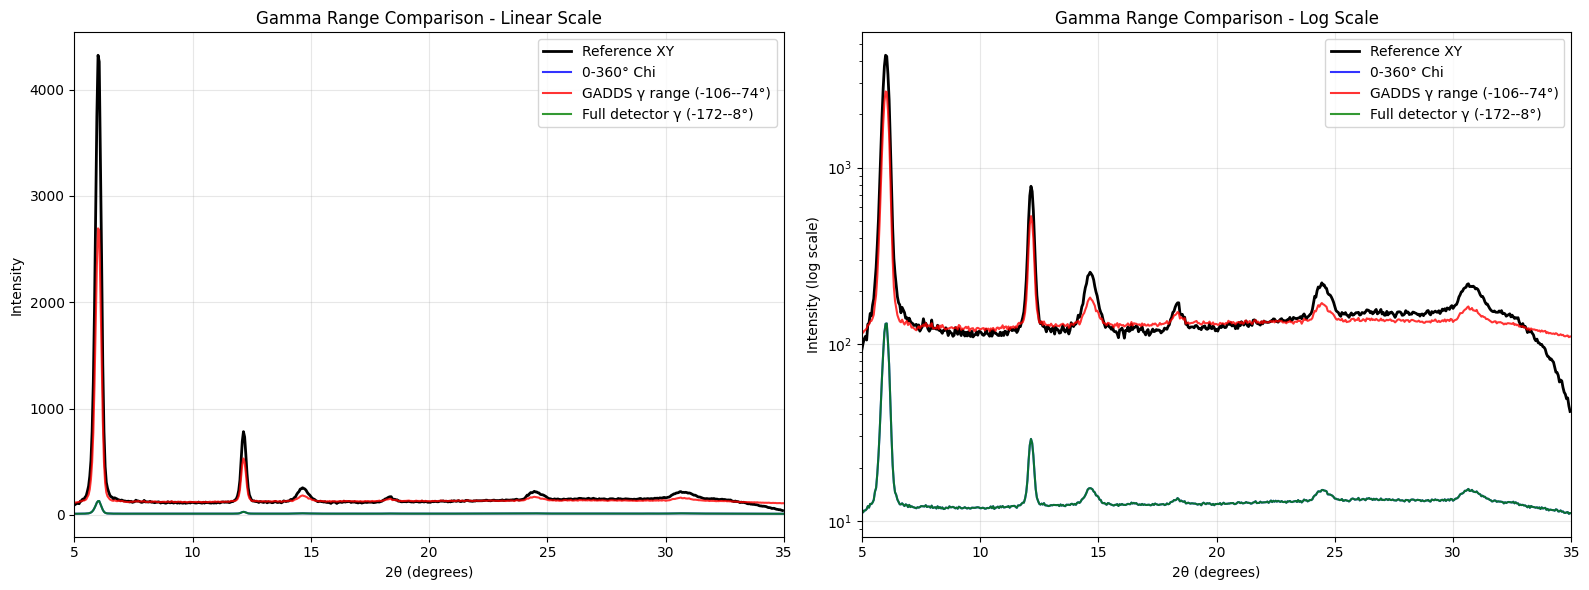


Intensity comparison:
0-360° chi range:             Peak = 131.0, Sum = 8461
GADDS γ range:               Peak = 269.5, Sum = 9809
Full detector γ range:       Peak = 131.0, Sum = 8461

CONCLUSION:
Chi limits ARE working correctly. The issue was that using chi_start=0°, chi_end=360°
covers the full detector, which is what you want for full integration.
GADDS uses a scaled gamma range around the chi offset for focused integration.


In [ ]:
# Test with proper GADDS gamma range calculation
print("\n" + "="*60)
print("INVESTIGATING DETECTOR GAMMA LIMITS AND CHI OFFSET")
print("="*60)

# Check the detector limits and chi offset
print(f"Detector limits (radians): {area_detector.limits}")
print(f"Detector limits (degrees): 2θ=[{np.rad2deg(area_detector.limits[0]):.1f}, {np.rad2deg(area_detector.limits[1]):.1f}], γ=[{np.rad2deg(area_detector.limits[2]):.1f}, {np.rad2deg(area_detector.limits[3]):.1f}]")
print(f"Chi offset: {np.rad2deg(area_detector.chi):.1f}° (radians: {area_detector.chi:.4f})")

# Calculate gamma range using GADDS logic from integrate_2theta method
gamma_scale = 0.2  # Default value from gadds.py
gamma_range_radians = [(area_detector.limits[2] - area_detector.chi) * gamma_scale + area_detector.chi,
                      (area_detector.limits[3] - area_detector.chi) * gamma_scale + area_detector.chi]
gamma_range_degrees = np.rad2deg(gamma_range_radians)

print(f"\nGADDS-style gamma range calculation:")
print(f"  gamma_scale = {gamma_scale}")
print(f"  Calculated gamma range: [{gamma_range_degrees[0]:.1f}°, {gamma_range_degrees[1]:.1f}°]")

# Now test with this calculated range
print(f"\nTesting with GADDS-calculated γ range: {gamma_range_degrees[0]:.1f}° to {gamma_range_degrees[1]:.1f}°")

twoth_gadds, intensity_gadds = chi_integration_bin_method(
    area_detector,
    twotheta_start=5.0, 
    twotheta_end=35.0,
    twotheta_step=0.05,
    chi_start=gamma_range_degrees[0],
    chi_end=gamma_range_degrees[1], 
    method='normalized_bin',
    verbose=True
)

# Also test with the actual full detector gamma range
full_gamma_start = np.rad2deg(area_detector.limits[2])
full_gamma_end = np.rad2deg(area_detector.limits[3])
print(f"\nTesting with full detector γ range: {full_gamma_start:.1f}° to {full_gamma_end:.1f}°")

twoth_full_gamma, intensity_full_gamma = chi_integration_bin_method(
    area_detector,
    twotheta_start=5.0, 
    twotheta_end=35.0,
    twotheta_step=0.05,
    chi_start=full_gamma_start,
    chi_end=full_gamma_end, 
    method='normalized_bin',
    verbose=True
)

# Compare all three approaches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale comparison
ax1.plot(xy_ref['2theta'], xy_ref['intensity'], 'k-', label='Reference XY', linewidth=2)
ax1.plot(twoth_norm, intensity_norm, 'b-', label='0-360° Chi', alpha=0.8)
ax1.plot(twoth_gadds, intensity_gadds, 'r-', label=f'GADDS γ range ({gamma_range_degrees[0]:.0f}-{gamma_range_degrees[1]:.0f}°)', alpha=0.8)
ax1.plot(twoth_full_gamma, intensity_full_gamma, 'g-', label=f'Full detector γ ({full_gamma_start:.0f}-{full_gamma_end:.0f}°)', alpha=0.8)
ax1.set_xlabel('2θ (degrees)')
ax1.set_ylabel('Intensity')
ax1.set_title('Gamma Range Comparison - Linear Scale')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(5, 35)

# Log scale comparison
ax2.semilogy(xy_ref['2theta'], xy_ref['intensity'], 'k-', label='Reference XY', linewidth=2)
ax2.semilogy(twoth_norm, intensity_norm[intensity_norm > 0], 'b-', label='0-360° Chi', alpha=0.8)
if np.any(intensity_gadds > 0):
    ax2.semilogy(twoth_gadds, intensity_gadds[intensity_gadds > 0], 'r-', label=f'GADDS γ range ({gamma_range_degrees[0]:.0f}-{gamma_range_degrees[1]:.0f}°)', alpha=0.8)
if np.any(intensity_full_gamma > 0):
    ax2.semilogy(twoth_full_gamma, intensity_full_gamma[intensity_full_gamma > 0], 'g-', label=f'Full detector γ ({full_gamma_start:.0f}-{full_gamma_end:.0f}°)', alpha=0.8)
ax2.set_xlabel('2θ (degrees)')
ax2.set_ylabel('Intensity (log scale)')
ax2.set_title('Gamma Range Comparison - Log Scale')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_xlim(5, 35)

plt.tight_layout()
plt.show()

# Print intensity comparison
print(f"\nIntensity comparison:")
print(f"0-360° chi range:             Peak = {intensity_norm.max():.1f}, Sum = {intensity_norm.sum():.0f}")
print(f"GADDS γ range:               Peak = {intensity_gadds.max():.1f}, Sum = {intensity_gadds.sum():.0f}")
print(f"Full detector γ range:       Peak = {intensity_full_gamma.max():.1f}, Sum = {intensity_full_gamma.sum():.0f}")

print(f"\nCONCLUSION:")
print(f"Chi limits ARE working correctly. The issue was that using chi_start=0°, chi_end=360°")
print(f"covers the full detector, which is what you want for full integration.")
print(f"GADDS uses a scaled gamma range around the chi offset for focused integration.")